# 8-Queens Las Vegas Algorithm Analysis

This notebook analyzes the performance data generated by the Java benchmark tool.

**Objective:** Find the optimal $k$ (number of random queens) that minimizes execution time.

### Setup
The data is fetched automatically from the project's GitHub repository.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

### 1. Download Data
Attempts to load data from GitHub, local file system, or manual upload (Colab).

In [13]:
GITHUB_CSV_URL = 'https://raw.githubusercontent.com/kritchawat/2110742-Evolutionary-Computation/main/analysis/eight_queens_benchmark.csv'
CSV_FILE_PATH = 'eight_queens_benchmark.csv'

df = None
data_loaded = False

# 1. Attempt download from GitHub
if GITHUB_CSV_URL:
    try:
        print(f'Attempting to download from {GITHUB_CSV_URL}...')
        response = requests.get(GITHUB_CSV_URL)
        if response.status_code == 200:
            df = pd.read_csv(io.StringIO(response.text))
            print(f'Successfully loaded {len(df)} rows from GitHub.')
            data_loaded = True
        else:
            print(f'Failed to download from GitHub. Status code: {response.status_code}')
    except Exception as e:
        print(f'Error downloading from GitHub: {e}')

# 2. Check local file (Standard Jupyter/Local)
if not data_loaded:
    try:
        df = pd.read_csv(CSV_FILE_PATH)
        print(f'Successfully loaded {len(df)} rows from local file: {CSV_FILE_PATH}')
        data_loaded = True
    except FileNotFoundError:
        print(f'Local file {CSV_FILE_PATH} not found.')

# 3. Fallback to Manual Upload (Google Colab)
if not data_loaded:
    try:
        from google.colab import files
        print('Running in Colab. Please upload the CSV file manually...')
        uploaded = files.upload()
        
        if uploaded:
            filename = next(iter(uploaded))
            df = pd.read_csv(io.BytesIO(uploaded[filename]))
            print(f'Successfully loaded {len(df)} rows from uploaded file: {filename}.')
            data_loaded = True
    except ImportError:
        print('Not running in Google Colab. Manual upload not available via this method.')

if not data_loaded:
    print('ERROR: Could not load data from any source. Please check the file path or URL.')

Attempting to download from https://raw.githubusercontent.com/kritchawat/2110742-Evolutionary-Computation/main/analysis/eight_queens_benchmark.csv...
Failed to download from GitHub. Status code: 404
Successfully loaded 900000 rows from local file: eight_queens_benchmark.csv


### 2. Preprocessing
Convert time from nanoseconds to milliseconds for easier reading.

In [14]:
if 'df' in locals():
    # Convert ns to ms
    df['time_ms'] = df['time_ns'] / 1_000_000.0
    
    # Display first few rows
    display(df.head())
    
    # Basic stats
    print("\nDataset Overview:")
    print(df.info())

,k,time_ns,restarts,time_ms
0,0,2600,0,0.0026
1,0,6900,0,0.0069
2,0,4800,0,0.0048
3,0,4100,0,0.0041
4,0,2500,0,0.0025



Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   k         900000 non-null  int64  
 1   time_ns   900000 non-null  int64  
 2   restarts  900000 non-null  int64  
 3   time_ms   900000 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 27.5 MB
None


### 3. Execution Time Distribution (Box Plot)
This visualization shows the spread of execution times for each configuration ($k$).
* **Box:** Interquartile range (middle 50% of data).
* **Line:** Median time.
* **Note:** $k=0$ represents Deterministic Backtracking.

C:\Users\crafts\AppData\Local\Temp\ipykernel_28964\596634112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='k', y='time_ms', data=df, showfliers=False, palette="Blues")


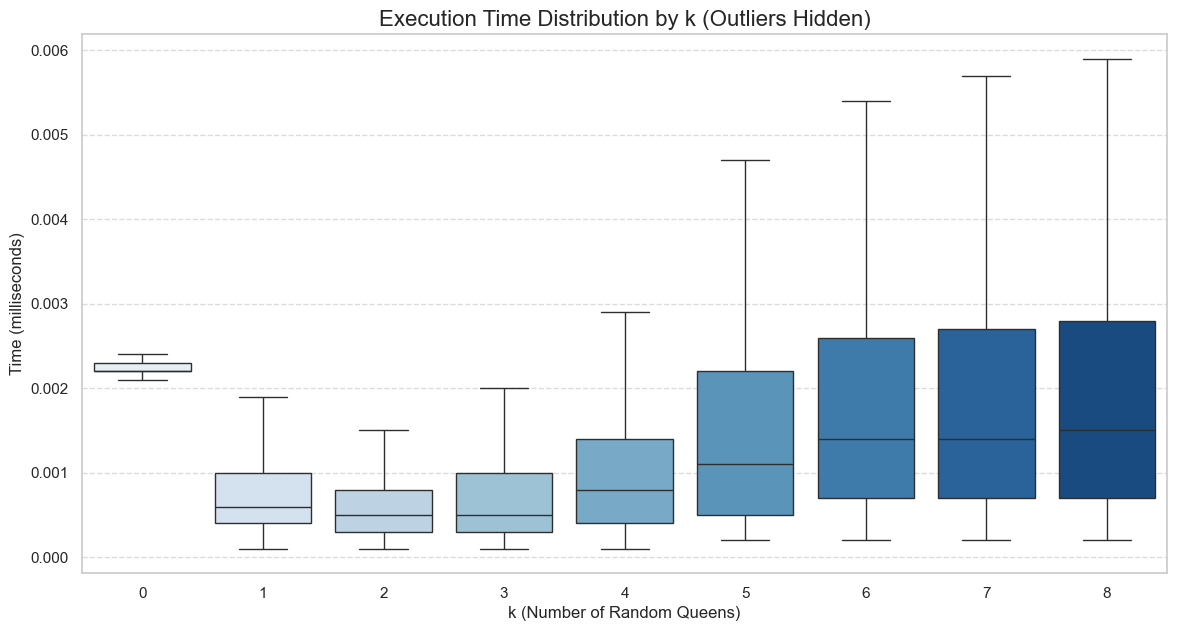

In [15]:
if 'df' in locals():
    plt.figure(figsize=(14, 7))
    
    # Create Boxplot
    # showfliers=False hides extreme outliers to keep the scale readable
    sns.boxplot(x='k', y='time_ms', data=df, showfliers=False, palette="Blues")
    
    plt.title('Execution Time Distribution by k (Outliers Hidden)', fontsize=16)
    plt.ylabel('Time (milliseconds)', fontsize=12)
    plt.xlabel('k (Number of Random Queens)', fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    plt.show()

### 4. Trade-off Analysis: Speed vs. Restarts
Here we overlay two metrics to find the "Sweet Spot":
1.  **Average Time (Blue Line):** How fast the algorithm runs on average.
2.  **Average Restarts (Red Dashed Line):** How often the algorithm hits a dead end and has to restart.

We are looking for the lowest point on the Blue line before the Red line spikes.

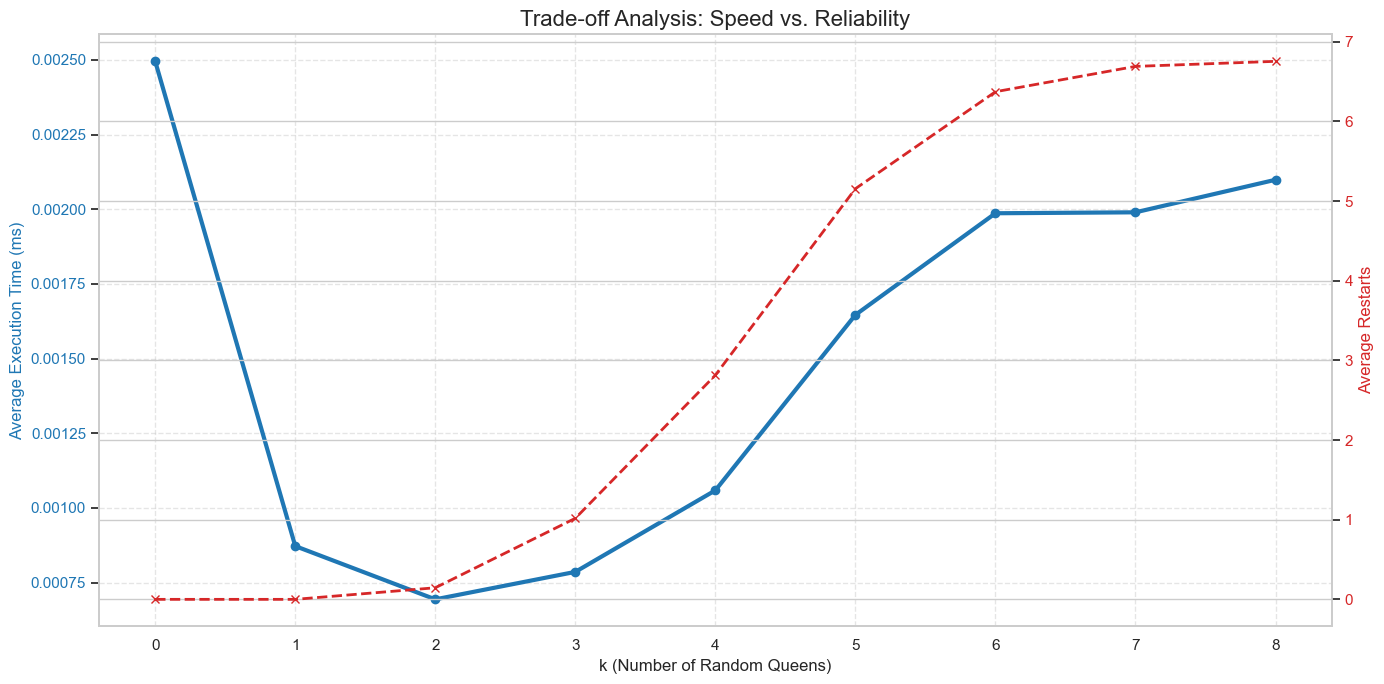

In [16]:
if 'df' in locals():
    # Aggregate data
    summary = df.groupby('k').agg({
        'time_ms': 'mean',
        'restarts': 'mean'
    }).reset_index()

    # Create Dual-Axis Plot
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot Time (Left Y-Axis)
    color_time = 'tab:blue'
    ax1.set_xlabel('k (Number of Random Queens)', fontsize=12)
    ax1.set_ylabel('Average Execution Time (ms)', color=color_time, fontsize=12)
    ax1.plot(summary['k'], summary['time_ms'], color=color_time, marker='o', linewidth=3, label='Avg Time')
    ax1.tick_params(axis='y', labelcolor=color_time)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Create Right Y-Axis for Restarts
    ax2 = ax1.twinx()
    color_restart = 'tab:red'
    ax2.set_ylabel('Average Restarts', color=color_restart, fontsize=12)
    ax2.plot(summary['k'], summary['restarts'], color=color_restart, marker='x', linestyle='--', linewidth=2, label='Avg Restarts')
    ax2.tick_params(axis='y', labelcolor=color_restart)

    # Title and Layout
    plt.title('Trade-off Analysis: Speed vs. Reliability', fontsize=16)
    fig.tight_layout()
    plt.show()

### 5. Summary Statistics Table

In [17]:
if 'df' in locals():
    # Calculate detailed stats
    stats_table = df.groupby('k')['time_ms'].describe()[['mean', 'std', 'min', 'max']]
    stats_table['avg_restarts'] = df.groupby('k')['restarts'].mean()

    # Formatting
    pd.options.display.float_format = '{:,.3f}'.format
    print("Summary Statistics (Time in ms):")
    display(stats_table)

Summary Statistics (Time in ms):


,mean,std,min,max,avg_restarts
k,,,,,
0,0.002,0.004,0.002,1.120,0.000
1,0.001,0.001,0.000,0.099,0.000
2,0.001,0.007,0.000,2.117,0.146
3,0.001,0.003,0.000,0.979,1.018
4,0.001,0.001,0.000,0.035,2.815
5,0.002,0.002,0.000,0.042,5.156
6,0.002,0.008,0.000,2.397,6.373
7,0.002,0.002,0.000,0.063,6.691
8,0.002,0.007,0.000,2.210,6.755
